# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Load data
df_hist = pd.read_csv('../solutions/hist.csv')
df_recent = pd.read_csv('../solutions/recent.csv')

# Standardize categories
df_hist['Category'] = df_hist['Category'].str.upper().str.replace('/', ' ')
df_recent['Category'] = df_recent['Incident Category'].str.upper().str.replace('/', ' ')

crime_map = {
    'DRUG NARCOTIC': 'DRUG OFFENSE', 
    'MOTOR VEHICLE THEFT': 'VEHICLE THEFT', 
    'LARCENY/THEFT': 'LARCENY THEFT'
}
df_hist['Category'] = df_hist['Category'].replace(crime_map)
df_recent['Category'] = df_recent['Category'].replace(crime_map)

# Select essential columns
h = df_hist[['Category', 'PdDistrict', 'Date', 'Time', 'X', 'Y']].copy()
r = df_recent[['Category', 'Police District', 'Incident Date', 'Incident Time', 'Longitude', 'Latitude']].copy()
r.columns = h.columns

# Merge datasets
df = pd.concat([h, r], ignore_index=True)
df['PdDistrict'] = df['PdDistrict'].str.upper()

# Clean data
df = df.dropna(subset=['X', 'Y', 'Date', 'Time'])
df = df[(df['X'] < -122.3) & (df['X'] > -122.6) & (df['Y'] < 37.9) & (df['Y'] > 37.6)]
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Define Personal Focus Crimes
focus_crimes = [
    'LARCENY THEFT', 'BURGLARY', 'DRUG OFFENSE', 
    'VEHICLE THEFT', 'ROBBERY', 'VANDALISM', 
    'ASSAULT', 'PROSTITUTION'
]
df_focus = df[df['Category'].isin(focus_crimes)].copy()
print(f"Successfully merged and cleaned {len(df)} incidents.")

C:\Users\FrederikSunesen\AppData\Local\Temp\ipykernel_37576\2001120761.py:10: DtypeWarning: Columns (0: Intersection, 1: Analysis Neighborhood, 2: Point) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recent = pd.read_csv('../solutions/recent.csv')


Successfully merged and cleaned 3031463 incidents.


---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

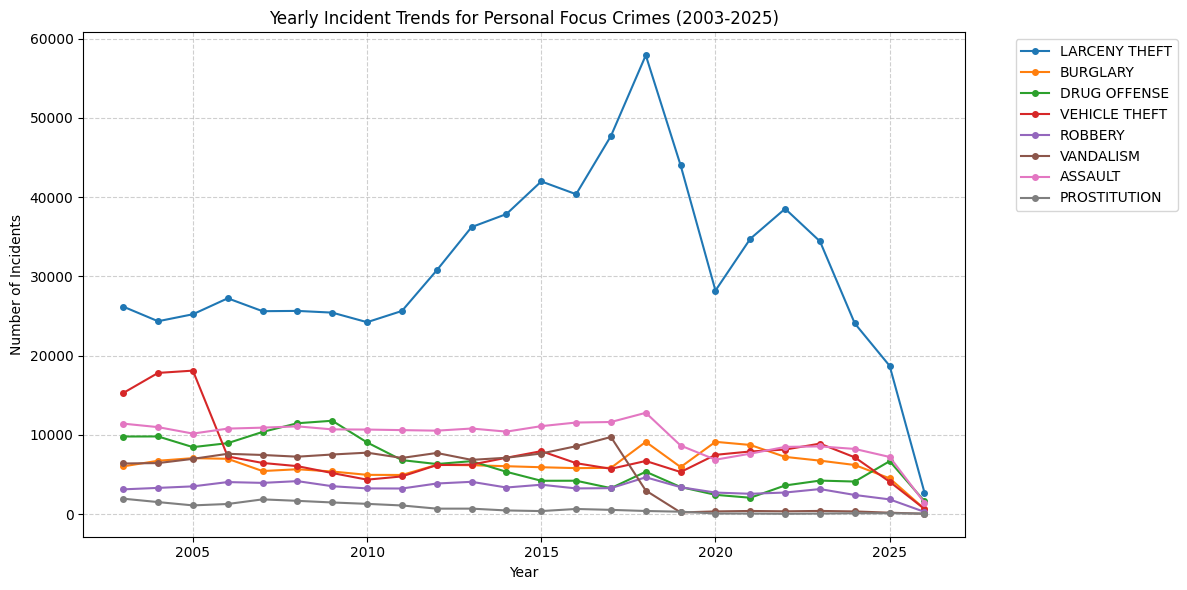

In [56]:
df_focus['Year'] = df_focus['Date'].dt.year
yearly_counts = df_focus.groupby(['Year', 'Category']).size().unstack()

plt.figure(figsize=(12, 6))
for crime in focus_crimes:
    plt.plot(yearly_counts.index, yearly_counts[crime], marker='o', markersize=4, label=crime)

plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.title('Yearly Incident Trends for Personal Focus Crimes (2003-2025)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Interpretation:
1. **The Larceny Peak (2015-2018):** The plot shows a massive, sustained rise in Larceny. Beyond just having more expensive phones to steal, this suggests that the 'opportunity' for this type of crime became much more common during this period. It looks like a systemic change in how property crime occurred in the city, rather than a one-off spike.
2. **The COVID-19 Flip (2020):** There is a very clear 'inverse' relationship in 2020. Larceny and Assault dropped because these crimes usually happen in crowds or on busy streets - which disappeared during lockdowns. On the other hand, Burglary went up, likely because commercial buildings were left empty and unguarded for months, making them easier targets.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

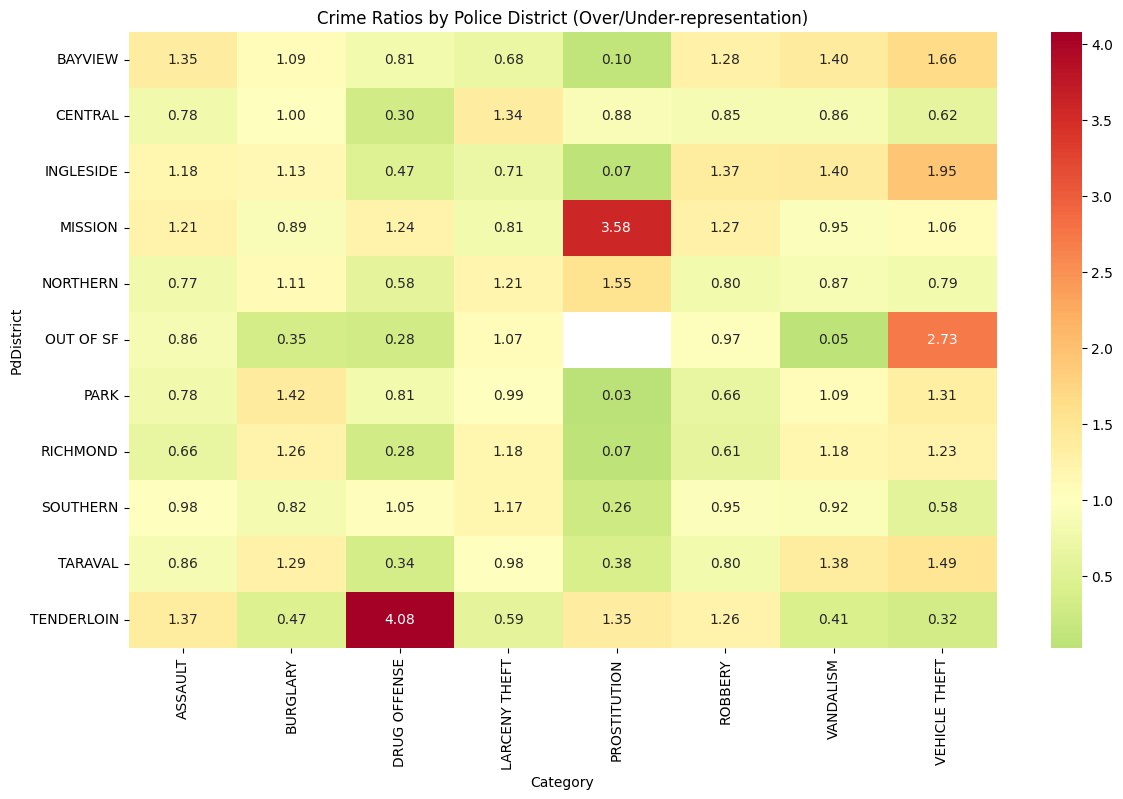

In [57]:
p_crime = df_focus['Category'].value_counts(normalize=True)
p_crime_district = df_focus.groupby('PdDistrict')['Category'].value_counts(normalize=True).unstack()
ratios = p_crime_district.div(p_crime, axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(ratios, annot=True, cmap='RdYlGn_r', center=1, fmt=".2f")
plt.title('Crime Ratios by Police District (Over/Under-representation)')
plt.show()

Interpretation:
**The Tenderloin Anomaly:** The extreme concentration of **DRUG OFFENSES** in the Tenderloin stands out because its ratio is over 4.0. This means drugs are not just slightly more common there; they are a defining characteristic of the district's crime profile compared to the rest of the city. It seems that this district is where San Francisco street-level drug activity is most heavily localized.

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?

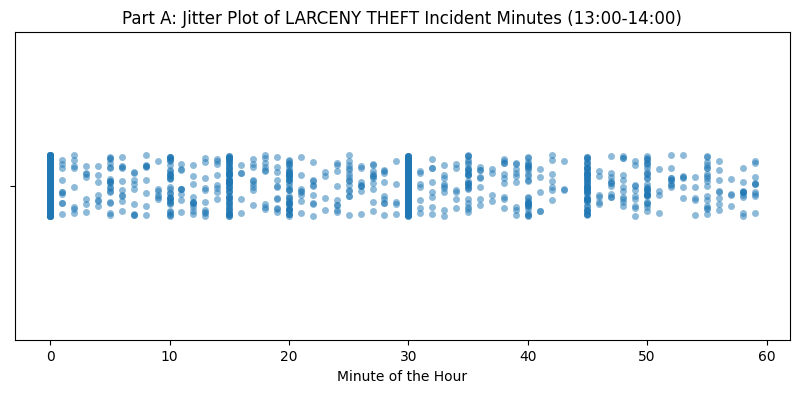

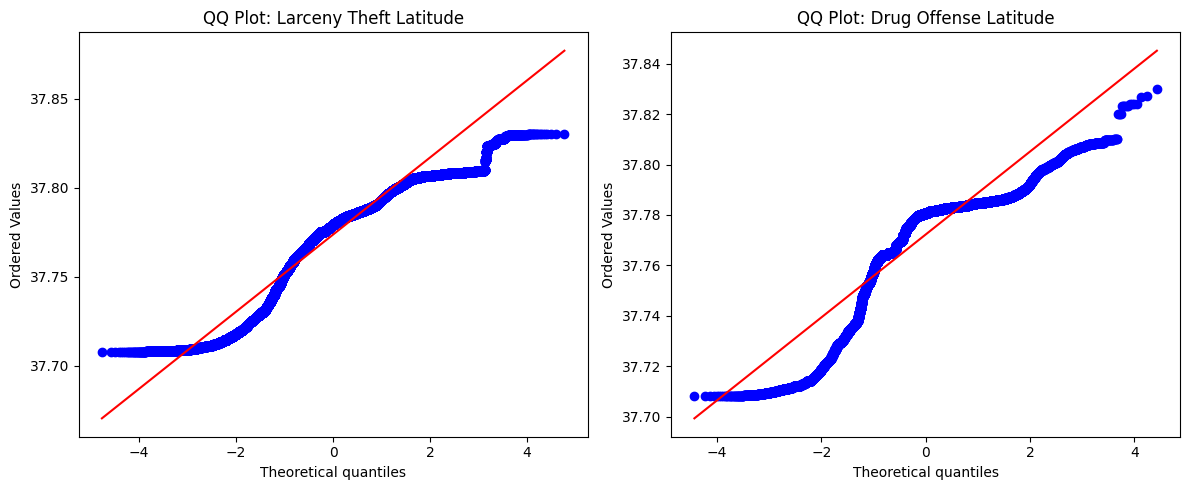

C:\Users\FrederikSunesen\AppData\Local\Temp\ipykernel_37576\3634265267.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_focus, x='Category', y='Hour', palette="muted")


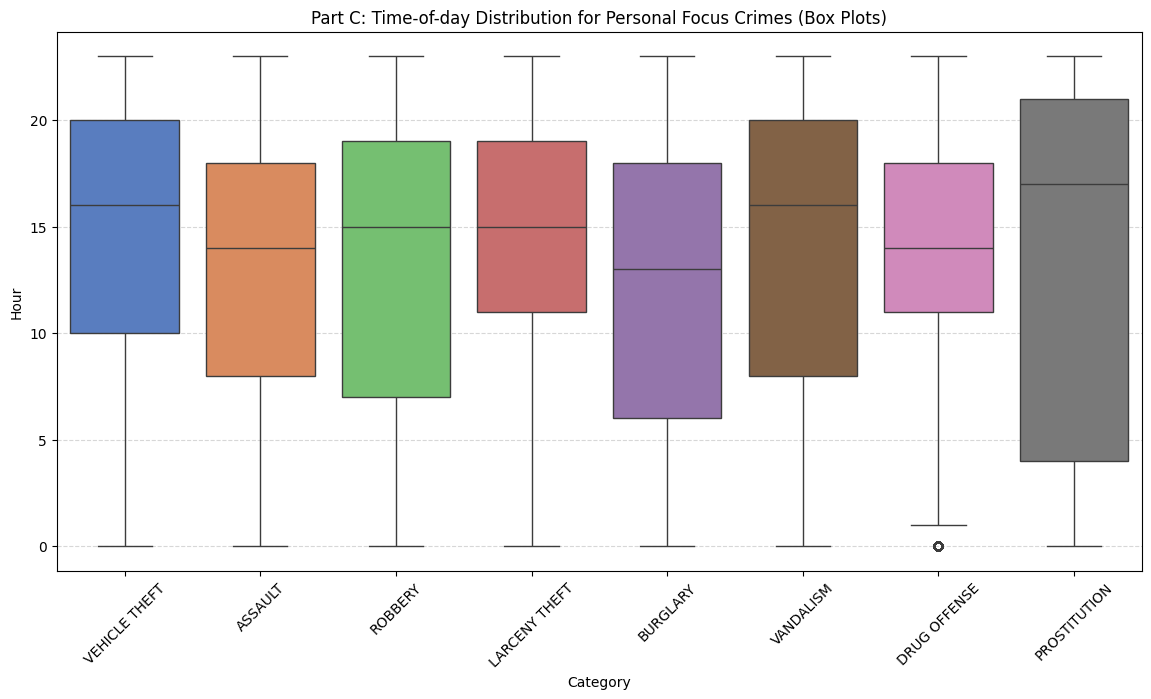

In [58]:
# Part A - Jitter Plot
crime_type = 'LARCENY THEFT'
df['Time_dt'] = pd.to_datetime(df['Time'], format='mixed')
df['Hour'] = df['Time_dt'].dt.hour
df['Minute'] = df['Time_dt'].dt.minute
jitter_data = df[(df['Category'] == crime_type) & (df['Date'].dt.year == 2024) & (df['Hour'] == 13)]

plt.figure(figsize=(10, 4))
sns.stripplot(x=jitter_data['Minute'], jitter=True, alpha=0.5)
plt.title(f'Part A: Jitter Plot of {crime_type} Incident Minutes (13:00-14:00)')
plt.xlabel('Minute of the Hour')
plt.show()

# Part B - QQ Plot
lat1 = df[df['Category'] == 'LARCENY THEFT']['Y']
lat2 = df[df['Category'] == 'DRUG OFFENSE']['Y']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(lat1, dist="norm", plot=ax1)
ax1.set_title('QQ Plot: Larceny Theft Latitude')
stats.probplot(lat2, dist="norm", plot=ax2)
ax2.set_title('QQ Plot: Drug Offense Latitude')
plt.tight_layout()
plt.show()

# Part C - Box plots of time-of-day
df_focus['Hour'] = pd.to_datetime(df_focus['Time'], format='mixed').dt.hour
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_focus, x='Category', y='Hour', palette="muted")
plt.title('Part C: Time-of-day Distribution for Personal Focus Crimes (Box Plots)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Interpretation:
**Part A (Jitter Plots):** The clustering of points at the 00, 15, 30, and 45-minute marks shows that crime reports are not recorded in real time. This is clearly a case of 'rounding' in human memory. When people report a crime later, they recall it as 'around quarter past' or 'on the hour,' which creates these artificial-looking stripes in the data.

**Part B (QQ Plots):** The fact that the points curve away from the straight line at the ends means that crime is not spread out evenly (or normally distributed). Instead, there are specific spots in the city that have many more incidents than a standard distribution would predict. Essentially, it confirms the existence of extreme hotspots.

**Part C (Box Plots):** The box plot fails at midnight because the clock is circular, but the plot is linear. 23:59 and 00:01 are actually only 2 minutes apart, but the box plot treats them as opposite ends of the day. This 'breaks' the visual representation for crimes that peak late at night, giving a misleading plot.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics?

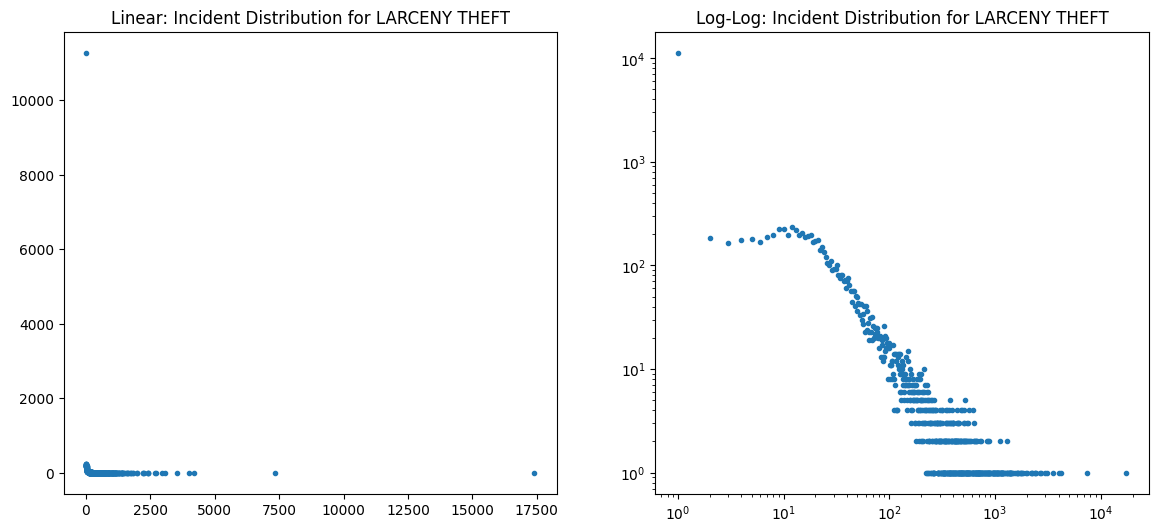

In [59]:
most_common = df_focus['Category'].value_counts().idxmax()
crime_data = df_focus[df_focus['Category'] == most_common]
x_bins = np.arange(-122.52, -122.35, 0.001)
y_bins = np.arange(37.70, 37.82, 0.001)
H, _, _ = np.histogram2d(crime_data['X'], crime_data['Y'], bins=(x_bins, y_bins))
counts = H.flatten()
k_vals, N_k = np.unique(counts, return_counts=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(k_vals + 1, N_k, 'o', markersize=3)
ax1.set_title(f'Linear: Incident Distribution for {most_common}')
ax2.loglog(k_vals + 1, N_k, 'o', markersize=3)
ax2.set_title(f'Log-Log: Incident Distribution for {most_common}')
plt.show()

Interpretation:
**Log-log Insight:** The linear trend on the log-log axis shows that a huge number of 100x100m cells have zero or very little crime, while a tiny handful of cells have hundreds or thousands of incidents. This power-law distribution tells us that SF's crime profile is dominated by extreme hotspots rather than being evenly spread across neighborhoods.

**Conclusion:** This means that a districts 'average' crime rate is very misleading. For example, if a neighborhood has a high crime rate, it might actually just have one or two very crime-rich street corners, while most of the neighborhood is perfectly safe.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week**.
> * **Scatterplot matrix**: pairwise scatterplots.
> * **Linear regression**: fit manually using closed-form equations.
> * **$R^2$**: compute and display.

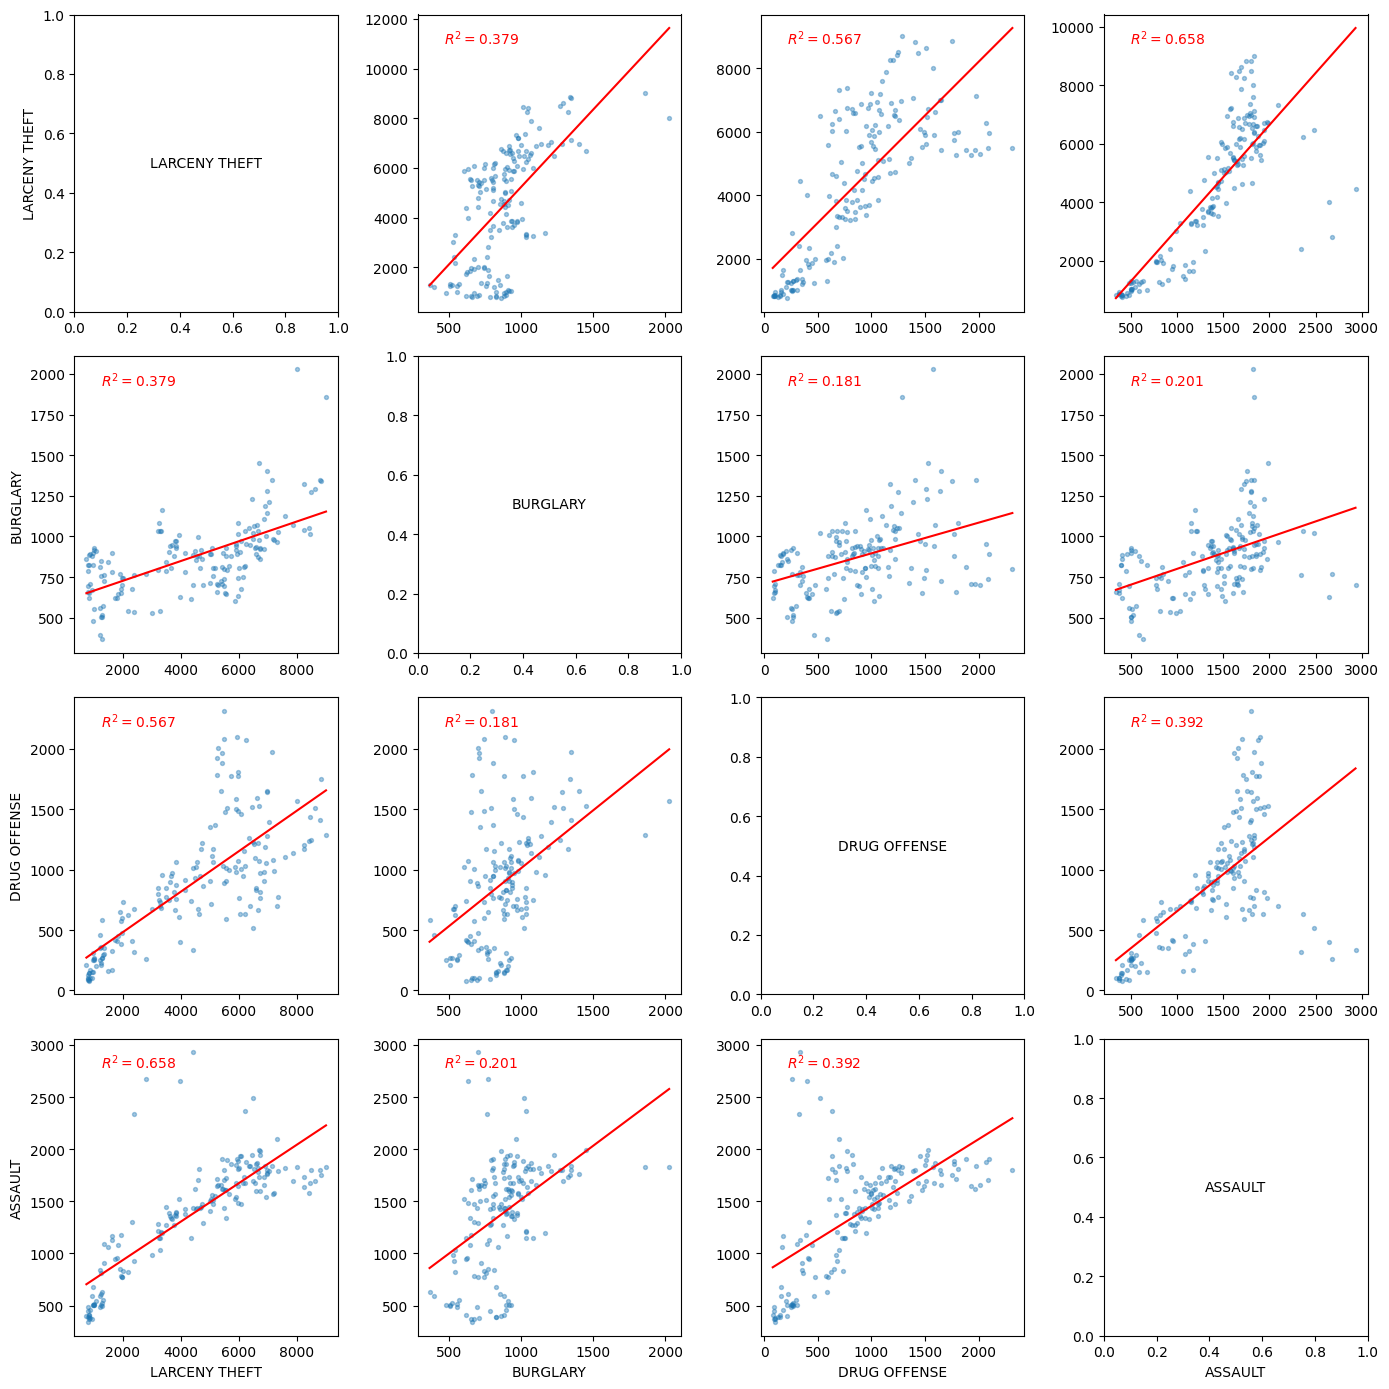

In [60]:
df_focus['DayOfWeek'] = df_focus['Date'].dt.dayofweek
df_focus['HourOfWeek'] = df_focus['DayOfWeek'] * 24 + df_focus['Hour']
selected_crimes = ['LARCENY THEFT', 'BURGLARY', 'DRUG OFFENSE', 'ASSAULT']
vectors = {c: df_focus[df_focus['Category'] == c].groupby('HourOfWeek').size().reindex(range(168), fill_value=0).values for c in selected_crimes}

def fit_manual_regression(x, y):
    n = len(x)
    x_mean, y_mean = np.mean(x), np.mean(y)
    a = (np.sum(x * y) - n * x_mean * y_mean) / (np.sum(x**2) - n * x_mean**2)
    b = y_mean - a * x_mean
    y_pred = a * x + b
    r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y_mean)**2))
    return a, b, r2

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, c1 in enumerate(selected_crimes):
    for j, c2 in enumerate(selected_crimes):
        ax = axes[i, j]
        if i == j:
            ax.text(0.5, 0.5, c1, ha='center', va='center')
        else:
            x, y = vectors[c2], vectors[c1]
            ax.scatter(x, y, s=8, alpha=0.4)
            a, b, r2 = fit_manual_regression(x, y)
            x_line = np.array([min(x), max(x)])
            ax.plot(x_line, a * x_line + b, color='red')
            ax.text(0.1, 0.9, f'$R^2 = {r2:.3f}$', transform=ax.transAxes, fontsize=10, fontweight='bold', color='red')
        if i == 3: ax.set_xlabel(c2)
        if j == 0: ax.set_ylabel(c1)
plt.tight_layout()
plt.show()

Interpretation:
**The City tendency:** The high correlation between **Larceny and Assault** is interesting because they are different types of crime (one is property, the other is person-to-person). However, both likely depend on how many people are on the streets. When the city is busy, there are both more people to pickpocket and more social friction that leads to assaults.

**Different Patterns:** On the other hand, crimes like Burglary don't follow this same rhythm. This tells us that San Francisco has multiple 'crime ecosystems.' Some happen in public when it is busy, while others happen when the streets are empty (or even in private settings).

**Contributions:** As I am the only group member, I am responsible for all work done (Frederik Sunesen)